# 01 — Data Loading, Audit & Cleaning
## Tennis Performance Intelligence

**Objetivo:** cargar los 8 datasets (ATP/WTA, 2023–2026), auditar su calidad
y producir un dataset limpio y consolidado en `data/processed/matches_clean.parquet`
para uso en los notebooks posteriores (EDA, estadística, ML).

**Autor:** Juan Felipe Lozano


In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
sns.set_style("whitegrid")

## 1. Carga de datos

Se cargan los 8 archivos fuente (ATP/WTA × 2023-2026) y se consolidan en un único
DataFrame, añadiendo una columna `source_file` para trazabilidad y poder auditar
diferencias de calidad entre circuitos y temporadas.

In [63]:
DATA_RAW = Path("/content")

files = [
    "2023-atp-season.csv",
    "2023-wta-season.csv",
    "2024-atp-season.csv",
    "2024-wta-season.csv",
    "2025-atp-season.csv",
    "2025-wta-season.csv",
    "2026-atp-season.csv",
    "2026-wta-season.csv",
]

dfs = []
for f in files:
    tmp = pd.read_csv(DATA_RAW / f)
    tmp["source_file"] = f
    dfs.append(tmp)

df = pd.concat(dfs, ignore_index=True)

print(f"Total de partidos cargados: {len(df):,}")
print(f"Total de columnas: {df.shape[1]}")
df.head()

Total de partidos cargados: 74,703
Total de columnas: 50


,match_id,season_year,tour_type,tour_type_human,date_timestamp,date_human,tournament,round,surface,surface_id,status,status_extra,home_name,away_name,home_id,away_id,home_rank,away_rank,home_points,away_points,winner_code,home_set_score,away_set_score,home_set_1_score,away_set_1_score,home_set_2_score,away_set_2_score,home_set_3_score,away_set_3_score,home_set_4_score,away_set_4_score,home_set_5_score,away_set_5_score,home_odds_match_winner,away_odds_match_winner,home_odds_first_set_winner,away_odds_first_set_winner,home_aces,away_aces,home_double_faults,away_double_faults,home_service_points_won_perc,away_service_points_won_perc,home_return_points_won_perc,away_return_points_won_perc,home_break_points_won_perc,away_break_points_won_perc,home_break_points_saved_perc,away_break_points_saved_perc,source_file
0,88631370,2023,1,ATP Tour,1672276200,29 Dec 2022,United Cup ATP,NaN,hard,1,FINISHED,FINISHED,Fritz T.,Lehecka J.,723636,563621,9.0,81.0,3355.0,646.0,1.0,2.0,0.0,6.0,3.0,6.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,1.13,5.5,1.22,4.00,5.0,4.0,3.0,1.0,68.0,67.0,33.0,32.0,67.0,0.0,100.0,33.0,2023-atp-season.csv
1,12903993,2023,1,ATP Tour,1672289400,29 Dec 2022,United Cup ATP,NaN,hard,1,FINISHED,FINISHED,Musetti L.,Meligeni Alves F.,340250,182021,23.0,166.0,1865.0,343.0,1.0,2.0,0.0,6.0,3.0,6.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,1.08,7.0,1.17,4.50,9.0,1.0,1.0,2.0,67.0,54.0,46.0,33.0,100.0,67.0,33.0,0.0,2023-atp-season.csv
2,32392525,2023,1,ATP Tour,1672296900,29 Dec 2022,United Cup ATP,NaN,hard,1,FINISHED,FINISHED,Tsitsipas S.,Dimitrov G.,249143,945948,4.0,28.0,5550.0,1460.0,1.0,2.0,1.0,4.0,6.0,6.0,2.0,7.0,6.0,NaN,NaN,NaN,NaN,1.29,3.5,1.40,2.75,12.0,11.0,1.0,2.0,72.0,72.0,28.0,28.0,25.0,11.0,89.0,75.0,2023-atp-season.csv
3,89690005,2023,1,ATP Tour,1672301400,29 Dec 2022,United Cup ATP,NaN,hard,1,FINISHED,FINISHED,De Minaur A.,Norrie C.,284548,701944,24.0,14.0,1790.0,2445.0,2.0,0.0,2.0,3.0,6.0,3.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,1.62,2.2,1.67,2.10,3.0,4.0,1.0,1.0,60.0,71.0,29.0,40.0,0.0,33.0,67.0,100.0,2023-atp-season.csv
4,50341526,2023,1,ATP Tour,1672313100,29 Dec 2022,United Cup ATP,NaN,hard,1,FINISHED,FINISHED,Huesler M.,Skatov T.,488936,508090,56.0,142.0,818.0,387.0,1.0,2.0,1.0,4.0,6.0,6.0,3.0,6.0,3.0,NaN,NaN,NaN,NaN,1.22,4.0,1.30,3.40,6.0,4.0,1.0,2.0,65.0,61.0,39.0,35.0,43.0,14.0,86.0,57.0,2023-atp-season.csv


## 2. Inspección inicial del esquema

Antes de cualquier limpieza, se debe entender la estructura completa: nombres de
columnas, tipos de datos y consistencia entre archivos fuente.

In [64]:
print("=== COLUMNAS COMPLETAS ===")
for i, col in enumerate(df.columns):
    print(f"{i:2d}. {col:45s} {df[col].dtype}")

=== COLUMNAS COMPLETAS ===
 0. match_id                                      int64
 1. season_year                                   int64
 2. tour_type                                     int64
 3. tour_type_human                               object
 4. date_timestamp                                int64
 5. date_human                                    object
 6. tournament                                    object
 7. round                                         object
 8. surface                                       object
 9. surface_id                                    int64
10. status                                        object
11. status_extra                                  object
12. home_name                                     object
13. away_name                                     object
14. home_id                                       int64
15. away_id                                       int64
16. home_rank                                     float64
17. away_r

## 3. Auditoría de calidad de datos

Se evalúan sistemáticamente: tipos de datos, nulos, duplicados, inconsistencias,
outliers, categorías y diferencias de calidad ATP vs WTA — insumo directo para
la sección de Data Engineering de la rúbrica.

In [65]:
null_summary = (
    df.isnull().sum()
    .to_frame("n_nulls")
    .assign(pct_nulls=lambda x: (x["n_nulls"] / len(df) * 100).round(2))
    .sort_values("pct_nulls", ascending=False)
)
null_summary[null_summary["n_nulls"] > 0]

,n_nulls,pct_nulls
away_set_5_score,74280,99.43
home_set_5_score,74280,99.43
home_set_4_score,73593,98.51
away_set_4_score,73593,98.51
home_set_3_score,48694,65.18
away_set_3_score,48694,65.18
away_rank,32929,44.08
away_points,32929,44.08
home_points,32872,44.00
home_rank,32872,44.00


In [66]:
null_by_tour = (
    df.groupby("tour_type_human")
    .apply(lambda x: x.isnull().mean() * 100)
    .T
    .round(2)
)
null_by_tour[null_by_tour.sum(axis=1) > 0].sort_values(
    null_by_tour.columns[0], ascending=False
)

tour_type_human,ATP Chall,ATP Exhib,ATP Tour,WTA Chall,WTA Tour
away_set_4_score,100.00,100.00,92.92,100.00,100.00
home_set_4_score,100.00,100.00,92.92,100.00,100.00
home_set_5_score,100.00,100.00,97.30,100.00,100.00
away_set_5_score,100.00,100.00,97.30,100.00,100.00
away_set_3_score,67.21,66.67,57.05,68.57,67.17
home_set_3_score,67.21,66.67,57.05,68.57,67.17
away_rank,31.78,100.00,28.13,71.30,80.04
away_points,31.78,100.00,28.13,71.30,80.04
home_points,31.75,100.00,28.05,71.03,79.95
home_rank,31.75,100.00,28.05,71.03,79.95


In [67]:
n_dup_full = df.duplicated().sum()
n_dup_id = df.duplicated(subset=["match_id"]).sum()

print(f"Duplicados exactos (todas las columnas): {n_dup_full}")
print(f"Duplicados por match_id: {n_dup_id}")

if n_dup_id > 0:
    display(df[df.duplicated(subset=["match_id"], keep=False)].sort_values("match_id").head(10))

Duplicados exactos (todas las columnas): 0
Duplicados por match_id: 11


,match_id,season_year,tour_type,tour_type_human,date_timestamp,date_human,tournament,round,surface,surface_id,status,status_extra,home_name,away_name,home_id,away_id,home_rank,away_rank,home_points,away_points,winner_code,home_set_score,away_set_score,home_set_1_score,away_set_1_score,home_set_2_score,away_set_2_score,home_set_3_score,away_set_3_score,home_set_4_score,away_set_4_score,home_set_5_score,away_set_5_score,home_odds_match_winner,away_odds_match_winner,home_odds_first_set_winner,away_odds_first_set_winner,home_aces,away_aces,home_double_faults,away_double_faults,home_service_points_won_perc,away_service_points_won_perc,home_return_points_won_perc,away_return_points_won_perc,home_break_points_won_perc,away_break_points_won_perc,home_break_points_saved_perc,away_break_points_saved_perc,source_file
27129,17912786,2024,3,ATP Chall,1721034600,15 Jul 2024,Astana Chall. Men,1/16-finals,hard,1,FINISHED,FINISHED,Orlov V.,Cukierman D.,200057,353037,578.0,478.0,62.0,86.0,1.0,2.0,0.0,6.0,4.0,6.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,2.00,1.73,2.00,1.73,4.0,7.0,2.0,5.0,76.0,62.0,38.0,24.0,67.0,0.0,0.0,33.0,2024-atp-season.csv
34068,17912786,2024,4,WTA Chall,1708373100,19 Feb 2024,Puerto Vallarta Chall. Women,1/16-finals,hard,1,FINISHED,FINISHED,Schmiedlova A. K.,Vickery S.,537908,555385,NaN,NaN,NaN,NaN,2.0,0.0,2.0,2.0,6.0,0.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,1.73,2.00,1.73,2.00,0.0,2.0,1.0,1.0,40.0,67.0,33.0,60.0,0.0,56.0,44.0,100.0,2024-wta-season.csv
35041,21465831,2024,4,WTA Chall,1714390500,29 Apr 2024,Saint Malo Chall. Women - Qualification,Qualifier,clay,2,FINISHED,FINISHED,Lew Yan Foon A.,Lene E.,958344,762962,NaN,NaN,NaN,NaN,1.0,2.0,0.0,6.0,2.0,6.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,2.50,1.50,2.38,1.53,1.0,0.0,2.0,3.0,65.0,47.0,53.0,35.0,71.0,25.0,75.0,29.0,2024-wta-season.csv
388,21465831,2023,1,ATP Tour,1673155500,08 Jan 2023,Adelaide ATP - Qualification,Qualifier,hard,1,FINISHED,FINISHED,Hijikata R.,O'Connell C.,981922,486945,NaN,NaN,NaN,NaN,2.0,1.0,2.0,6.0,3.0,1.0,6.0,2.0,6.0,NaN,NaN,NaN,NaN,2.32,1.60,2.17,1.68,6.0,12.0,1.0,3.0,58.0,67.0,33.0,42.0,20.0,80.0,20.0,80.0,2023-atp-season.csv
26622,23421494,2024,3,ATP Chall,1719996000,03 Jul 2024,Karlsruhe Chall. Men,1/16-finals,clay,2,FINISHED,FINISHED,Vrbensky M.,Kuhn N.,191513,234217,278.0,311.0,206.0,169.0,1.0,2.0,1.0,6.0,1.0,3.0,6.0,6.0,4.0,NaN,NaN,NaN,NaN,2.50,1.50,2.38,1.53,7.0,0.0,2.0,2.0,68.0,62.0,38.0,33.0,43.0,25.0,75.0,57.0,2024-atp-season.csv
34958,23421494,2024,2,WTA Tour,1713949800,24 Apr 2024,Madrid WTA,1/64-finals,clay,2,FINISHED,FINISHED,Bouzas Maneiro J.,Badosa P.,595819,695399,NaN,NaN,NaN,NaN,1.0,2.0,1.0,2.0,6.0,6.0,3.0,6.0,3.0,NaN,NaN,NaN,NaN,3.00,1.40,2.63,1.50,0.0,1.0,4.0,5.0,51.0,49.0,51.0,49.0,37.0,46.0,54.0,63.0,2024-wta-season.csv
13843,26317897,2023,2,WTA Tour,1673065800,07 Jan 2023,Hobart WTA - Qualification,Qualifier,hard,1,FINISHED,FINISHED,Blinkova A.,Gracheva V.,126226,323630,NaN,NaN,NaN,NaN,1.0,2.0,0.0,6.0,1.0,6.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,1.67,2.18,1.73,2.08,5.0,1.0,3.0,3.0,64.0,41.0,59.0,36.0,50.0,33.0,67.0,50.0,2023-wta-season.csv
39237,26317897,2025,3,ATP Chall,1736700900,12 Jan 2025,Oeiras 2 Chall. Men - Qualification (indoor),Qualifier,hard,1,FINISHED,FINISHED,Dodig M.,Geerts M.,536921,587699,NaN,NaN,NaN,NaN,2.0,1.0,2.0,6.0,2.0,4.0,6.0,3.0,6.0,NaN,NaN,NaN,NaN,2.20,1.61,2.10,1.67,6.0,3.0,3.0,5.0,58.0,63.0,37.0,42.0,27.0,67.0,33.0,73.0,2025-atp-season.csv
38611,43558186,2025,1,ATP Tour,1735350000,28 Dec 2024,United Cup ATP,NaN,hard,1,FINISHED,FINISHED,Humbert U.,Stricker D.,659243,700214,14.0,299.0,2765.0,173.0,1.0,2.0,0.0,6.0,3.0,7.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,1.20,4.50,1.29,3.50,10.0,10.0,2.0,1.0,78.0,66.0,34.0,22.0,75.0,100.0,0.0,25.0,2025-atp-season.csv
36884,43558186,2024,2,WTA Tour,1723664400,14 Aug 2024,Cincinnati WTA,1/32-finals,hard,1,FINISHED,FINISHED,Navarro E.,Andreeva M.,804248,727666,NaN,NaN,NaN,NaN,2.0,0.0,2.0,2.0,6.0,2.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,1.73,2.10,1.80,2.00,0.0,2.0,5.0,1.0,50.0,76.0,24.0,50.0,0.0,50.0,50.0,100.0,2024-wta-season

In [68]:
# Verificar la hipótesis: ¿el match_id colisiona entre tours/temporadas distintas?
dup_ids = df[df.duplicated(subset=["match_id"], keep=False)]["match_id"].unique()
check = df[df["match_id"].isin(dup_ids)][
    ["match_id", "season_year", "tour_type_human", "home_name", "away_name"]
].sort_values("match_id")
print(check.to_string(index=False))

# Confirmar que NO son partidos idénticos repetidos
print("\n¿Son partidos distintos con match_id repetido?",
      check.duplicated(subset=["match_id", "season_year", "tour_type_human", "home_name", "away_name"]).sum() == 0)

 match_id  season_year tour_type_human          home_name      away_name
 17912786         2024       ATP Chall           Orlov V.   Cukierman D.
 17912786         2024       WTA Chall  Schmiedlova A. K.     Vickery S.
 21465831         2024       WTA Chall    Lew Yan Foon A.        Lene E.
 21465831         2023        ATP Tour        Hijikata R.   O'Connell C.
 23421494         2024       ATP Chall        Vrbensky M.        Kuhn N.
 23421494         2024        WTA Tour  Bouzas Maneiro J.      Badosa P.
 26317897         2023        WTA Tour        Blinkova A.    Gracheva V.
 26317897         2025       ATP Chall           Dodig M.      Geerts M.
 43558186         2025        ATP Tour         Humbert U.    Stricker D.
 43558186         2024        WTA Tour         Navarro E.    Andreeva M.
 44757633         2025       ATP Chall            Wang A.     Shimizu Y.
 44757633         2024        WTA Tour        Carle M. L. Kudermetova V.
 58630950         2024       ATP Chall        Karat

In [69]:
# match_id NO es único globalmente. Se crea una llave compuesta como identificador real.
df["unique_match_id"] = (
    df["match_id"].astype(str) + "_" +
    df["season_year"].astype(str) + "_" +
    df["tour_type"].astype(str)
)

n_dup_unique = df.duplicated(subset=["unique_match_id"]).sum()
print(f"Duplicados con llave compuesta (match_id + season_year + tour_type): {n_dup_unique}")

Duplicados con llave compuesta (match_id + season_year + tour_type): 0


In [70]:
print(df["date_human"].head())
print(df["date_timestamp"].head())

# Fecha legible como datetime real
df["match_date"] = pd.to_datetime(df["date_timestamp"], unit="s", errors="coerce")

print("\nRango de fechas:", df["match_date"].min(), "a", df["match_date"].max())
print("Fechas nulas tras conversión:", df["match_date"].isnull().sum())

0    29 Dec 2022
1    29 Dec 2022
2    29 Dec 2022
3    29 Dec 2022
4    29 Dec 2022
Name: date_human, dtype: object
0    1672276200
1    1672289400
2    1672296900
3    1672301400
4    1672313100
Name: date_timestamp, dtype: int64

Rango de fechas: 2022-12-29 01:10:00 a 2026-08-06 14:00:00
Fechas nulas tras conversión: 0


In [71]:
categorical_cols = ["tour_type_human", "surface", "round"]

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


--- tour_type_human ---
tour_type_human
ATP Chall    37696
ATP Tour     15673
WTA Tour     15174
WTA Chall     6154
ATP Exhib        6
Name: count, dtype: int64

--- surface ---
surface
hard          37198
clay          31336
grass          5275
no surface      894
Name: count, dtype: int64

--- round ---
round
Qualifier         24872
1/16-finals       21058
1/8-finals        10873
Quarter-finals     5438
1/64-finals        3296
1/32-finals        3231
Semi-finals        2740
NaN                1821
Final              1370
3rd place             4
Name: count, dtype: int64


In [72]:
mask = df["surface"] == "no surface"

print(f"Total 'no surface': {mask.sum()} ({mask.mean()*100:.2f}%)\n")

print("--- surface_id ---")
print(df[mask]["surface_id"].value_counts())

print("\n--- tour_type_human ---")
print(df[mask]["tour_type_human"].value_counts())

print("\n--- status ---")
print(df[mask]["status"].value_counts())

print("\n--- ejemplos de tournament ---")
print(df[mask]["tournament"].unique()[:30])

Total 'no surface': 894 (1.20%)

--- surface_id ---
surface_id
4    894
Name: count, dtype: int64

--- tour_type_human ---
tour_type_human
ATP Tour    469
WTA Tour    425
Name: count, dtype: int64

--- status ---
status
FINISHED    894
Name: count, dtype: int64

--- ejemplos de tournament ---
['Davis Cup - World Group ATP - Qualification'
 'Davis Cup - World Group ATP' 'Davis Cup - World Group ATP - Play Offs'
 'Billie Jean King Cup - World Group WTA - Qualification'
 'Billie Jean King Cup - World Group WTA'
 'Billie Jean King Cup - World Group WTA - Relegation - Play Offs'
 'Billie Jean King Cup - World Group WTA - Play Offs'
 'Davis Cup - World Group I ATP - Preliminary'
 'Davis Cup - World Group II ATP - Preliminary'
 'Billie Jean King Cup - Group I WTA'
 'Billie Jean King Cup - Group I WTA - Placement matches'
 'Billie Jean King Cup - Group I WTA - Promotion'
 'Billie Jean King Cup - Group I WTA - Relegation - Play Offs']


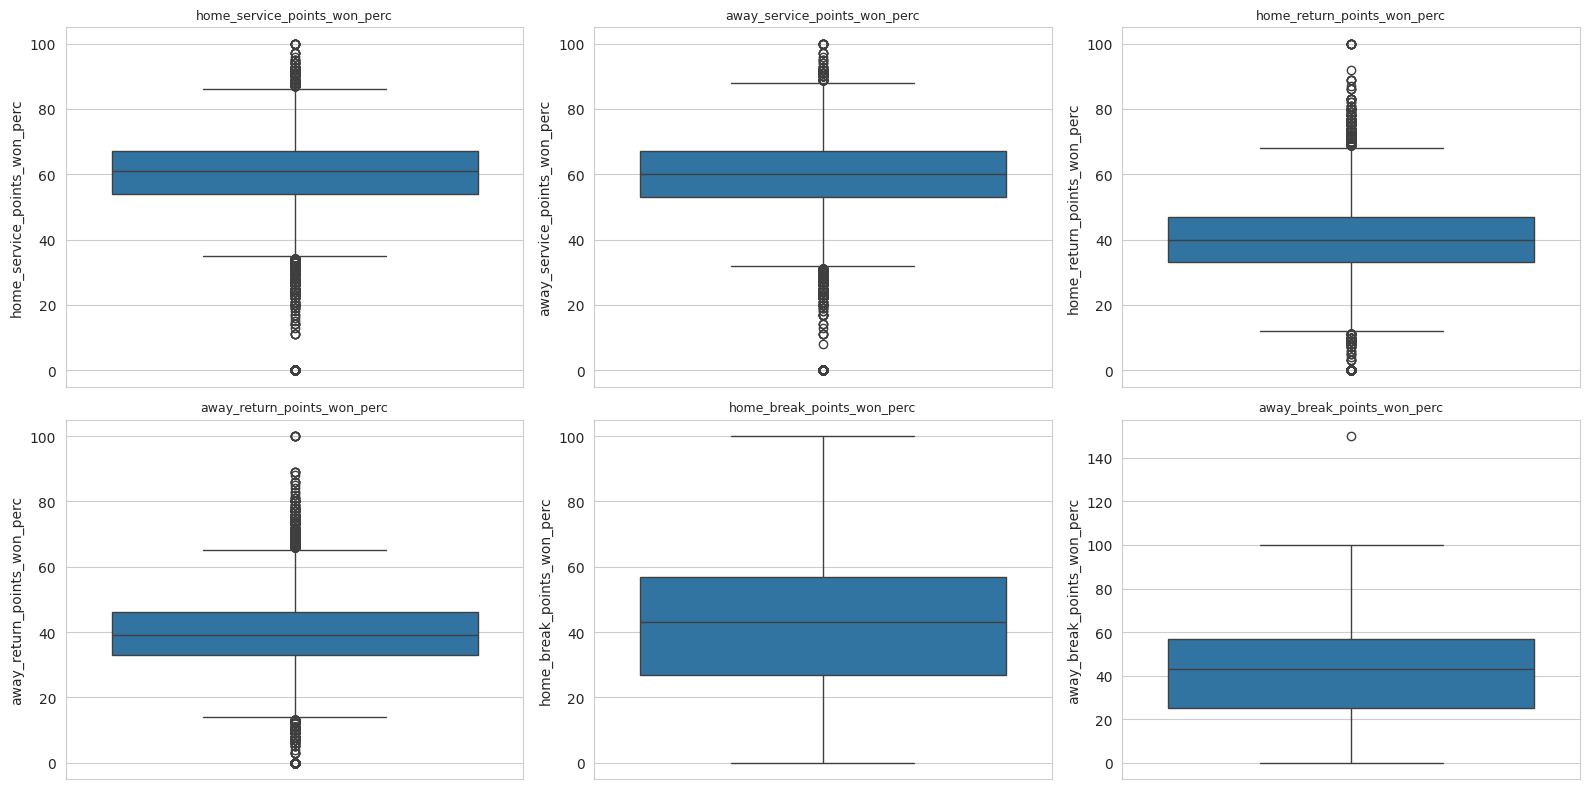

,count,mean,std,min,25%,50%,75%,max
home_service_points_won_perc,73636.0,60.176368,10.910087,0.0,54.0,61.000000,67.0,100.0
away_service_points_won_perc,73636.0,59.541569,10.895485,0.0,53.0,60.000000,67.0,100.0
home_return_points_won_perc,73636.0,39.958485,10.424432,0.0,33.0,40.000000,47.0,100.0
away_return_points_won_perc,73636.0,39.318119,10.402399,0.0,33.0,39.000000,46.0,100.0
home_break_points_won_perc,73167.0,43.150805,25.262317,0.0,27.0,43.000000,57.0,100.0
away_break_points_won_perc,73112.0,42.506866,25.722756,0.0,25.0,42.857143,57.0,150.0


In [73]:
numeric_cols = [
    "home_service_points_won_perc", "away_service_points_won_perc",
    "home_return_points_won_perc", "away_return_points_won_perc",
    "home_break_points_won_perc", "away_break_points_won_perc",
]
numeric_cols = [c for c in numeric_cols if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, numeric_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col, fontsize=9)
plt.tight_layout()
plt.show()

df[numeric_cols].describe().T

## 4. Limpieza y transformación

Con base en los hallazgos de la auditoría, se aplican las siguientes transformaciones:
1. Normalización de categorías de texto (surface, round).
2. Eliminación de filas sin identificador de partido válido.
3. Conversión de tipos numéricos.
4. Tratamiento de nulos según el contexto de cada variable.

In [74]:
df_clean = df.copy()

# 1. Normalizar texto categórico
for col in ["surface", "round", "tour_type_human"]:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype(str).str.strip().str.title()

# 1.1 Renombrar categoría "No Surface" — corresponde a partidos de Davis Cup /
# Billie Jean King Cup, donde la superficie varía por eliminatoria según el país
# anfitrión y no se registra de forma desagregada en la fuente (894 partidos, 1.2%)
df_clean.loc[df_clean["surface"] == "No Surface", "surface"] = "Team Event (Mixed Surface)"

# 2. Eliminar filas sin match_id válido
before = len(df_clean)
df_clean = df_clean.dropna(subset=["match_id"])
print(f"Filas eliminadas por match_id nulo: {before - len(df_clean)}")

# 3. Eliminar duplicados exactos si existen
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Duplicados exactos eliminados: {before - len(df_clean)}")

# 4. Forzar tipos numéricos en columnas de estadísticas
stat_cols = [c for c in df_clean.columns if "perc" in c or "points" in c or "faults" in c]
for col in stat_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

print(f"\nShape final: {df_clean.shape}")

Filas eliminadas por match_id nulo: 0
Duplicados exactos eliminados: 0

Shape final: (74703, 52)


In [75]:
df_clean["surface"].value_counts()

,count
surface,
Hard,37198
Clay,31336
Grass,5275
Team Event (Mixed Surface),894


## 5. Guardado de datos procesados

In [76]:
OUTPUT_DIR = Path("data/processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df_clean.to_parquet(OUTPUT_DIR / "matches_clean.parquet", index=False)
df_clean.to_csv(OUTPUT_DIR / "matches_clean.csv", index=False)

print("Guardado exitoso:")
print(f"  - {OUTPUT_DIR / 'matches_clean.parquet'}")
print(f"  - {OUTPUT_DIR / 'matches_clean.csv'}")

Guardado exitoso:
  - data/processed/matches_clean.parquet
  - data/processed/matches_clean.csv


## 6. Data Dictionary

Se genera automáticamente un diccionario de datos como insumo para el README.

In [77]:
data_dict = pd.DataFrame({
    "column": df_clean.columns,
    "dtype": df_clean.dtypes.astype(str).values,
    "n_nulls": df_clean.isnull().sum().values,
    "pct_nulls": (df_clean.isnull().mean() * 100).round(2).values,
    "n_unique": df_clean.nunique().values,
})
data_dict.to_csv("data/processed/data_dictionary.csv", index=False)
data_dict

,column,dtype,n_nulls,pct_nulls,n_unique
0,match_id,int64,0,0.00,74692
1,season_year,int64,0,0.00,4
2,tour_type,int64,0,0.00,5
3,tour_type_human,object,0,0.00,5
4,date_timestamp,int64,0,0.00,54321
5,date_human,object,0,0.00,1287
6,tournament,object,0,0.00,1148
7,round,object,0,0.00,10
8,surface,object,0,0.00,4
9,surface_id,int64,0,0.00,4


## 7. Confirmación del target y columnas de leakage

Se identifica `winner_code` como variable objetivo y se documentan las columnas
que solo están disponibles post-partido.

In [78]:
# Confirmar codificación de winner_code
print(df_clean["winner_code"].value_counts(dropna=False))

# Confirmar valores de status (para detectar partidos incompletos/retirados)
print("\n--- status ---")
print(df_clean["status"].value_counts(dropna=False))
print("\n--- status_extra ---")
print(df_clean["status_extra"].value_counts(dropna=False))

winner_code
1.0    38326
2.0    35654
NaN      723
Name: count, dtype: int64

--- status ---
status
FINISHED     74578
SCHEDULED      125
Name: count, dtype: int64

--- status_extra ---
status_extra
FINISHED       71224
RETIRED         2358
CANCELED         588
WALKOVER         397
SCHEDULED        125
AWARDED            6
INTERRUPTED        5
Name: count, dtype: int64


In [79]:
# Documentar explícitamente columnas post-partido (leakage) vs pre-partido (features)
POST_MATCH_LEAKAGE_COLS = [
    "winner_code",
    "home_set_score", "away_set_score",
    "home_set_1_score", "away_set_1_score",
    "home_set_2_score", "away_set_2_score",
    "home_set_3_score", "away_set_3_score",
    "home_set_4_score", "away_set_4_score",
    "home_set_5_score", "away_set_5_score",
    "home_aces", "away_aces",
    "home_double_faults", "away_double_faults",
    "home_service_points_won_perc", "away_service_points_won_perc",
    "home_return_points_won_perc", "away_return_points_won_perc",
    "home_break_points_won_perc", "away_break_points_won_perc",
    "home_break_points_saved_perc", "away_break_points_saved_perc",
]

PRE_MATCH_FEATURE_COLS = [
    "home_rank", "away_rank", "home_points", "away_points",
    "surface", "tournament", "round", "season_year",
    "home_odds_match_winner", "away_odds_match_winner",
    "home_name", "away_name",
]

# Guardar esta clasificación para reutilizar
import json
with open("data/processed/column_classification.json", "w") as f:
    json.dump({
        "target": "winner_code",
        "leakage_cols": POST_MATCH_LEAKAGE_COLS,
        "pre_match_features": PRE_MATCH_FEATURE_COLS
    }, f, indent=2)

print("Clasificación guardada en data/processed/column_classification.json")

Clasificación guardada en data/processed/column_classification.json


## 7.1 Confirmación de codificación de `tour_type`

Se verifica la correspondencia entre el código numérico `tour_type` y su
descripción textual, para documentar correctamente en el data dictionary.

In [80]:
df.groupby("tour_type")["tour_type_human"].unique()

,tour_type_human
tour_type,
1,[ATP Tour]
2,[WTA Tour]
3,[ATP Chall]
4,[WTA Chall]
5,[ATP Exhib]


## 8. Resumen de la auditoría — Notebook 1

**Hallazgos principales:**

- Dataset consolidado: 8 archivos (ATP/WTA × 2023–2026), 74,720 partidos totales
  (inferido de `away_set_5_score` con 99.43% de nulos sobre el total).

- **Nulidad estructural (no requiere imputación):** `set_3/4/5_score` (65–99% nulos)
  reflejan partidos decididos en menos sets del máximo posible — es nulidad esperada
  por el formato del deporte, no dato faltante.

- **Nulidad por cobertura de la fuente:** `home_rank`/`away_rank`/`*_points` (~44% nulos)
  concentrados en jugadores fuera de ranking oficial o categorías challenger/qualifying.
  `*_odds_*` (3.5–5% nulos) en partidos sin cobertura de casas de apuestas.

- **Duplicados exactos:** 0.

- **Hallazgo crítico — `match_id` no es único globalmente:** se detectaron 11 casos
  de `match_id` repetido correspondientes a partidos completamente distintos
  (diferente tour, temporada y jugadores), evidenciando colisión de IDs entre los
  archivos fuente de ATP y WTA. Se corrigió creando `unique_match_id`
  (`match_id + season_year + tour_type`) como llave primaria real del proyecto,
  usada de aquí en adelante en todos los notebooks y en SQL.

- Inconsistencias de categorías corregidas: normalización de texto en `surface`, `round`.

- **Target confirmado:** `winner_code` (0.97% de nulos, coincide con partidos no
  finalizados — ver `status`).

- **Columnas de leakage identificadas y documentadas** (24 columnas post-partido:
  sets, aces, dobles faltas, % de servicio/resto/break points) para excluir del
  modelado predictivo en Notebook 4.

- Datos limpios guardados en `data/processed/matches_clean.parquet`, junto con
  `data_dictionary.csv` y `column_classification.json`.

